In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

# 1) Load scoring JSON from Step_3 (much faster than recursive search)
# Direct path to avoid slow rglob() scanning through /runs/ with 100+ folders
step3_dir = Path('/home/khanh/Projects/DifficultyAgri/results/01_minneapple_yolo_copy_paste_augmentation_detection/Step_3_Scoring_Dataset')
preferred_names = {'score_results.json', 'scoring_results.json', 'detail_score.json'}

score_path = None
data = None

# Try the direct Step_3 path first
if step3_dir.exists():
    for fname in preferred_names:
        candidate = step3_dir / fname
        if candidate.exists():
            try:
                with open(candidate, 'r', encoding='utf-8') as f:
                    d = json.load(f)
                if isinstance(d, dict) and isinstance(d.get('image_difficulties'), list):
                    score_path = candidate
                    data = d
                    break
            except Exception as e:
                print(f"Failed to load {candidate}: {e}")

if score_path is None:
    raise FileNotFoundError(f'No scoring JSON with image_difficulties found in {step3_dir}')

image_difficulties = data['image_difficulties']
if len(image_difficulties) == 0:
    raise ValueError(f'Empty image_difficulties in {score_path}')

print(f'Loaded scoring file: {score_path}')
print(f'Number of images: {len(image_difficulties)}')

# 2) Build object-level arrays (size vs object score)
obj_sizes = []
obj_scores = []
for img in image_difficulties:
    for obj in img.get('objects_score', []):
        bbox = obj.get('bounding_box', {})
        w = bbox.get('width')
        h = bbox.get('height')
        s = obj.get('difficulty_score')
        if w is None or h is None or s is None:
            continue
        obj_sizes.append(float(w) * float(h))
        obj_scores.append(float(s))

obj_sizes = np.array(obj_sizes, dtype=float)
obj_scores = np.array(obj_scores, dtype=float)

# 3) Build image-level arrays (image score vs fp/miss rates)
img_scores = np.array([float(img['difficulty_score']) for img in image_difficulties], dtype=float)
fp_rates = np.array([float(img.get('false_positive_rate', np.nan)) for img in image_difficulties], dtype=float)
miss_rates = np.array([float(img.get('missed_detections_rate', np.nan)) for img in image_difficulties], dtype=float)

print(f'Object samples: {len(obj_scores)}')
print(f'Images with FP rate: {np.sum(~np.isnan(fp_rates))}')
print(f'Images with miss rate: {np.sum(~np.isnan(miss_rates))}')

Loaded scoring file: /home/khanh/Projects/DifficultyAgri/results/01_minneapple_yolo_copy_paste_augmentation_detection/Step_3_Scoring_Dataset/score_results.json
Number of images: 536
Object samples: 22815
Images with FP rate: 536
Images with miss rate: 536


Pearson(object_size, object_score): -0.4607
Spearman(object_size, object_score): -0.6521


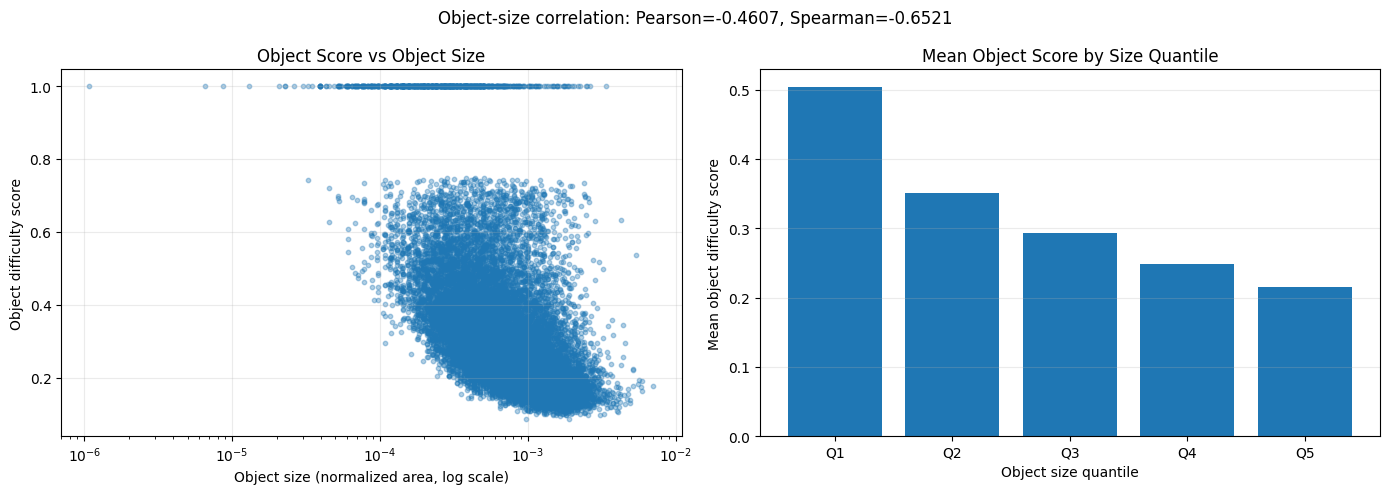

In [2]:
# Correlation 1: object size vs object score
if len(obj_scores) < 2:
    raise ValueError('Not enough object samples to compute correlation.')

safe_sizes = np.clip(obj_sizes, 1e-8, None)

pearson_obj = float(np.corrcoef(safe_sizes, obj_scores)[0, 1]) if not (np.allclose(safe_sizes, safe_sizes[0]) or np.allclose(obj_scores, obj_scores[0])) else float('nan')

# Spearman using rank transform (no scipy dependency)
def rankdata(arr):
    order = np.argsort(arr)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(arr), dtype=float)
    vals, inv, counts = np.unique(arr, return_inverse=True, return_counts=True)
    for i, c in enumerate(counts):
        if c > 1:
            idx = np.where(inv == i)[0]
            ranks[idx] = ranks[idx].mean()
    return ranks + 1.0

spearman_obj = float(np.corrcoef(rankdata(safe_sizes), rankdata(obj_scores))[0, 1])

print(f'Pearson(object_size, object_score): {pearson_obj:.4f}')
print(f'Spearman(object_size, object_score): {spearman_obj:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Scatter on log-size axis
ax[0].scatter(safe_sizes, obj_scores, s=10, alpha=0.35)
ax[0].set_xscale('log')
ax[0].set_xlabel('Object size (normalized area, log scale)')
ax[0].set_ylabel('Object difficulty score')
ax[0].set_title('Object Score vs Object Size')
ax[0].grid(alpha=0.25)

# Mean score by size quantile bins
q = np.quantile(safe_sizes, [0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
for i in range(1, len(q)):
    if q[i] <= q[i - 1]:
        q[i] = q[i - 1] + 1e-12
bins = np.digitize(safe_sizes, q[1:-1], right=True)
means = [float(np.mean(obj_scores[bins == i])) if np.any(bins == i) else np.nan for i in range(5)]
ax[1].bar(['Q1', 'Q2', 'Q3', 'Q4', 'Q5'], means)
ax[1].set_xlabel('Object size quantile')
ax[1].set_ylabel('Mean object difficulty score')
ax[1].set_title('Mean Object Score by Size Quantile')
ax[1].grid(axis='y', alpha=0.25)

fig.suptitle(f'Object-size correlation: Pearson={pearson_obj:.4f}, Spearman={spearman_obj:.4f}')
plt.tight_layout()
plt.show()

Pearson(image_score, false_positive_rate): 0.5501
Spearman(image_score, false_positive_rate): 0.5475


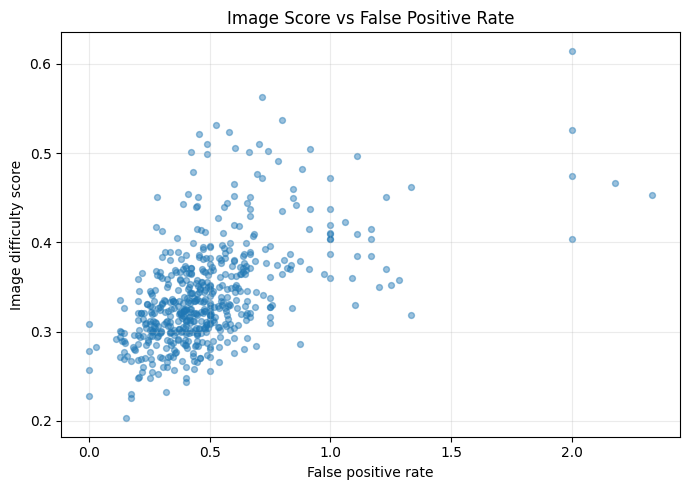

In [3]:
# Correlation 2: image score vs false positive rate
valid = ~np.isnan(fp_rates)
if np.sum(valid) < 2:
    raise ValueError('Not enough valid false_positive_rate values.')

x_fp = fp_rates[valid]
y_img_fp = img_scores[valid]

pearson_img_fp = float(np.corrcoef(x_fp, y_img_fp)[0, 1]) if not (np.allclose(x_fp, x_fp[0]) or np.allclose(y_img_fp, y_img_fp[0])) else float('nan')
spearman_img_fp = float(np.corrcoef(rankdata(x_fp), rankdata(y_img_fp))[0, 1])

print(f'Pearson(image_score, false_positive_rate): {pearson_img_fp:.4f}')
print(f'Spearman(image_score, false_positive_rate): {spearman_img_fp:.4f}')

plt.figure(figsize=(7, 5))
plt.scatter(x_fp, y_img_fp, s=18, alpha=0.45)
plt.xlabel('False positive rate')
plt.ylabel('Image difficulty score')
plt.title('Image Score vs False Positive Rate')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Pearson(image_score, missed_detections_rate): 0.6497
Spearman(image_score, missed_detections_rate): 0.5786


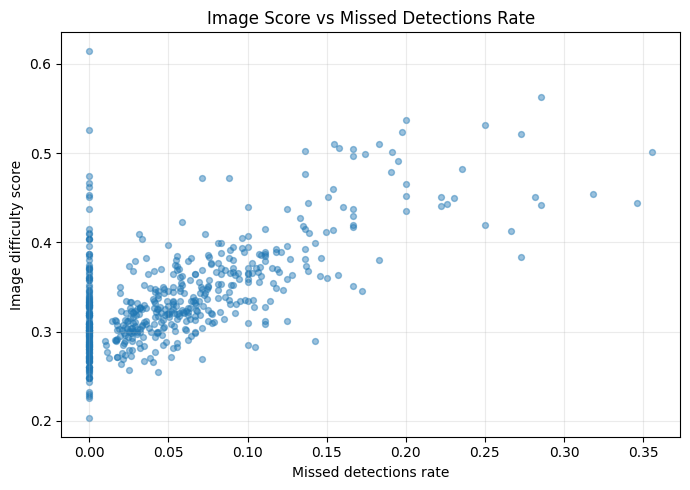

In [4]:
# Correlation 3: image score vs missed detections rate
valid = ~np.isnan(miss_rates)
if np.sum(valid) < 2:
    raise ValueError('Not enough valid missed_detections_rate values.')

x_miss = miss_rates[valid]
y_img_miss = img_scores[valid]

pearson_img_miss = float(np.corrcoef(x_miss, y_img_miss)[0, 1]) if not (np.allclose(x_miss, x_miss[0]) or np.allclose(y_img_miss, y_img_miss[0])) else float('nan')
spearman_img_miss = float(np.corrcoef(rankdata(x_miss), rankdata(y_img_miss))[0, 1])

print(f'Pearson(image_score, missed_detections_rate): {pearson_img_miss:.4f}')
print(f'Spearman(image_score, missed_detections_rate): {spearman_img_miss:.4f}')

plt.figure(figsize=(7, 5))
plt.scatter(x_miss, y_img_miss, s=18, alpha=0.45)
plt.xlabel('Missed detections rate')
plt.ylabel('Image difficulty score')
plt.title('Image Score vs Missed Detections Rate')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Image score count: 536
Mean: 0.3409, Std: 0.0586
Min: 0.2027, Max: 0.6148
Median: 0.3285


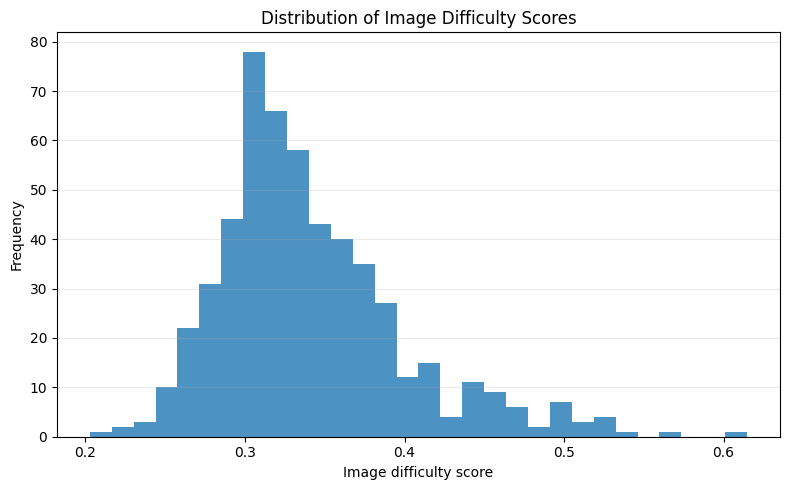

In [5]:
# Score distribution 1: image difficulty score distribution
if len(img_scores) == 0:
    raise ValueError('No image scores available.')

print(f'Image score count: {len(img_scores)}')
print(f'Mean: {np.mean(img_scores):.4f}, Std: {np.std(img_scores):.4f}')
print(f'Min: {np.min(img_scores):.4f}, Max: {np.max(img_scores):.4f}')
print(f'Median: {np.median(img_scores):.4f}')

plt.figure(figsize=(8, 5))
plt.hist(img_scores, bins=30, alpha=0.8)
plt.xlabel('Image difficulty score')
plt.ylabel('Frequency')
plt.title('Distribution of Image Difficulty Scores')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

Object score count: 22815
Mean: 0.3226, Std: 0.1844
Min: 0.0852, Max: 1.0000
Median: 0.2679


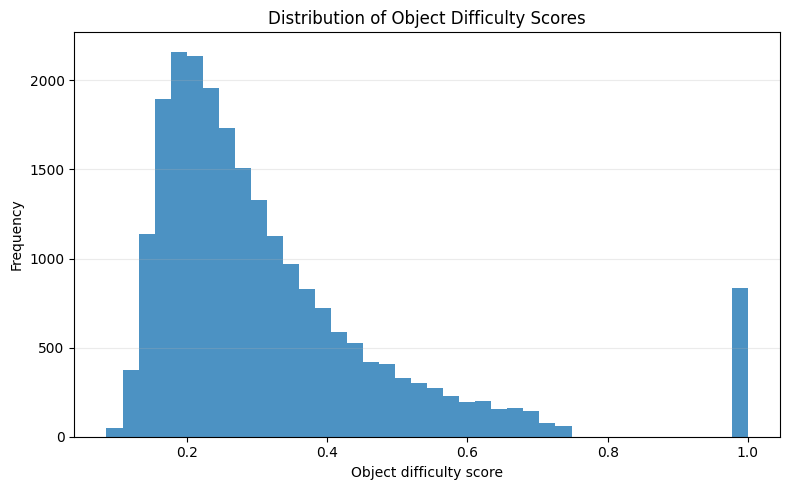

In [6]:
# Score distribution 2: object difficulty score distribution
if len(obj_scores) == 0:
    raise ValueError('No object scores available.')

print(f'Object score count: {len(obj_scores)}')
print(f'Mean: {np.mean(obj_scores):.4f}, Std: {np.std(obj_scores):.4f}')
print(f'Min: {np.min(obj_scores):.4f}, Max: {np.max(obj_scores):.4f}')
print(f'Median: {np.median(obj_scores):.4f}')

plt.figure(figsize=(8, 5))
plt.hist(obj_scores, bins=40, alpha=0.8)
plt.xlabel('Object difficulty score')
plt.ylabel('Frequency')
plt.title('Distribution of Object Difficulty Scores')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

In [7]:
# Visualization helpers for top/bottom score examples
from PIL import Image
import matplotlib.patches as patches


def resolve_image_path(path_str):
    if not path_str:
        return None
    p = Path(path_str)
    if p.exists():
        return p

    # Fallback by stem under dataset image folders
    stem = p.stem
    image_roots = [
        Path('/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/train/images'),
        Path('/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/val/images'),
        Path('/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/test/images'),
    ]
    for root in image_roots:
        for ext in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']:
            c = root / f'{stem}{ext}'
            if c.exists():
                return c
    return None


def draw_bbox(ax, bbox, img_w, img_h, color='red'):
    x_c = bbox.get('x_center', None)
    y_c = bbox.get('y_center', None)
    w = bbox.get('width', None)
    h = bbox.get('height', None)
    if x_c is None or y_c is None or w is None or h is None:
        return

    bw = float(w) * img_w
    bh = float(h) * img_h
    x0 = float(x_c) * img_w - bw / 2.0
    y0 = float(y_c) * img_h - bh / 2.0

    rect = patches.Rectangle((x0, y0), bw, bh, linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(rect)

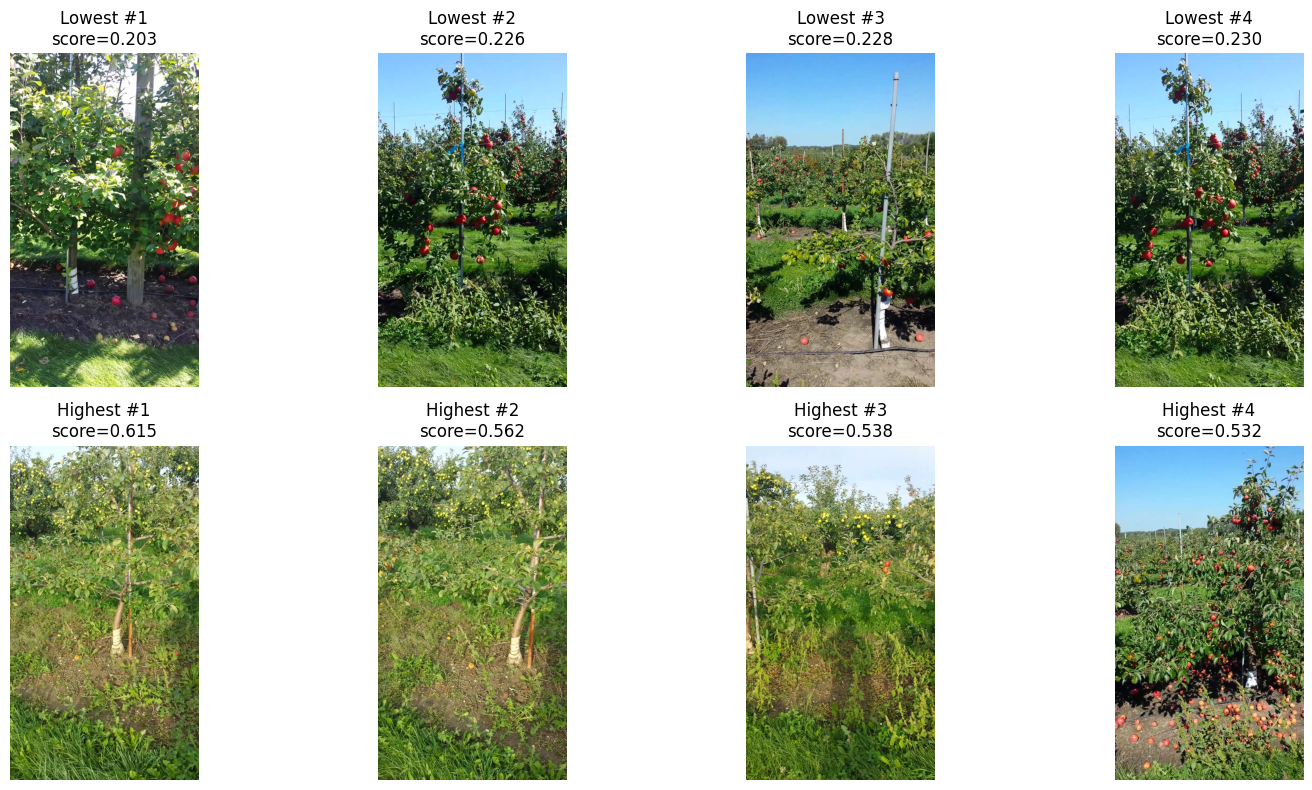

In [8]:
# Visualize images with highest and lowest image difficulty scores
k = 4
sorted_imgs = sorted(image_difficulties, key=lambda x: float(x.get('difficulty_score', 0.0)))
lowest_imgs = sorted_imgs[:k]
highest_imgs = sorted_imgs[-k:][::-1]

fig, axes = plt.subplots(2, k, figsize=(4 * k, 8))

for col, item in enumerate(lowest_imgs):
    p = resolve_image_path(item.get('image_path', ''))
    ax = axes[0, col]
    if p is None:
        ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
        ax.axis('off')
        continue
    im = Image.open(p).convert('RGB')
    ax.imshow(im)
    ax.set_title(f'Lowest #{col+1}\nscore={float(item.get("difficulty_score", 0.0)):.3f}')
    ax.axis('off')

for col, item in enumerate(highest_imgs):
    p = resolve_image_path(item.get('image_path', ''))
    ax = axes[1, col]
    if p is None:
        ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
        ax.axis('off')
        continue
    im = Image.open(p).convert('RGB')
    ax.imshow(im)
    ax.set_title(f'Highest #{col+1}\nscore={float(item.get("difficulty_score", 0.0)):.3f}')
    ax.axis('off')

axes[0, 0].set_ylabel('Lowest image scores', fontsize=11)
axes[1, 0].set_ylabel('Highest image scores', fontsize=11)
plt.tight_layout()
plt.show()

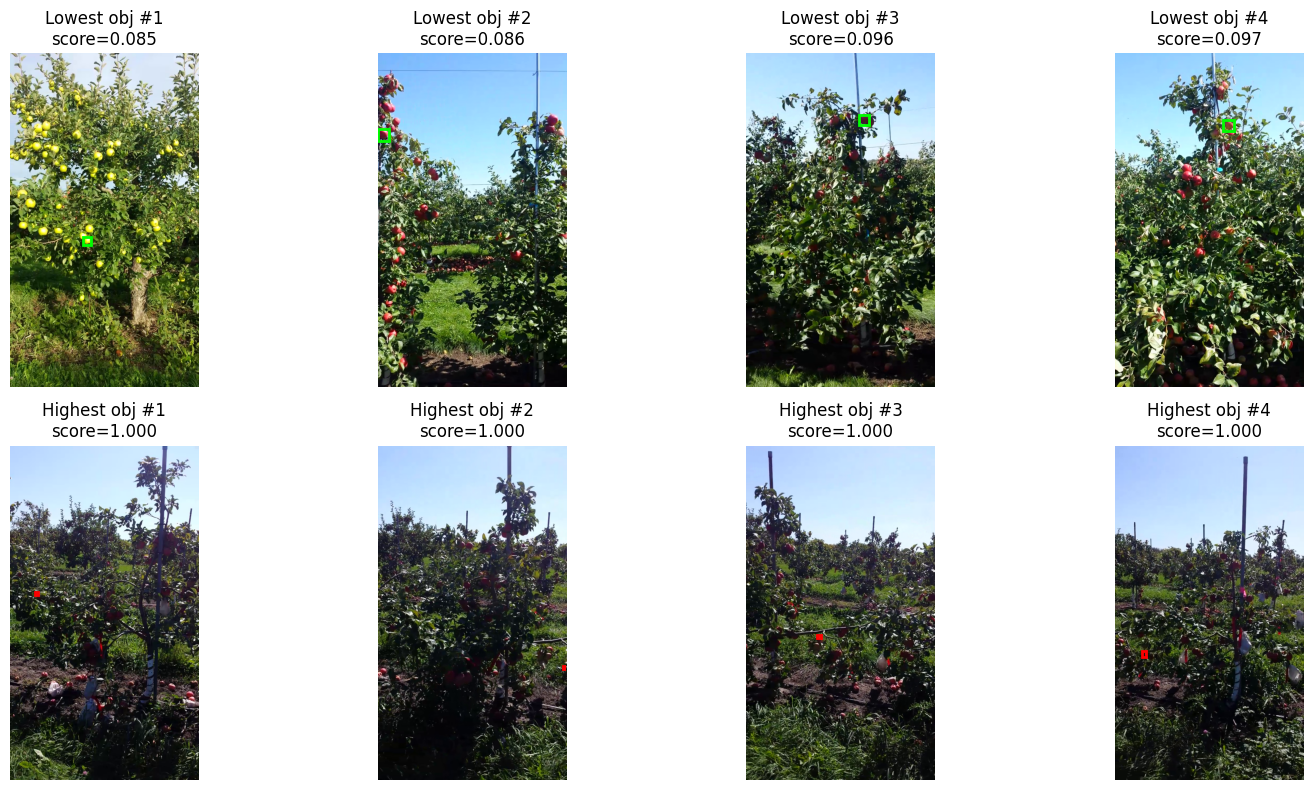

In [9]:
# Visualize objects with highest and lowest object difficulty scores (with bbox)
k = 4

all_objects = []
for img in image_difficulties:
    img_path = img.get('image_path', '')
    for obj in img.get('objects_score', []):
        score = float(obj.get('difficulty_score', 0.0))
        bbox = obj.get('bounding_box', {})
        all_objects.append({
            'image_path': obj.get('image_path', img_path),
            'score': score,
            'bbox': bbox,
            'class_id': obj.get('class_id', None),
            'object_id': obj.get('object_id', None),
        })

if len(all_objects) == 0:
    raise ValueError('No object-level entries found in image_difficulties.')

all_objects = sorted(all_objects, key=lambda x: x['score'])
lowest_objs = all_objects[:k]
highest_objs = all_objects[-k:][::-1]

fig, axes = plt.subplots(2, k, figsize=(4 * k, 8))

for col, item in enumerate(lowest_objs):
    ax = axes[0, col]
    p = resolve_image_path(item['image_path'])
    if p is None:
        ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
        ax.axis('off')
        continue

    im = Image.open(p).convert('RGB')
    w, h = im.size
    ax.imshow(im)
    draw_bbox(ax, item['bbox'], w, h, color='lime')
    ax.set_title(f'Lowest obj #{col+1}\nscore={item["score"]:.3f}')
    ax.axis('off')

for col, item in enumerate(highest_objs):
    ax = axes[1, col]
    p = resolve_image_path(item['image_path'])
    if p is None:
        ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
        ax.axis('off')
        continue

    im = Image.open(p).convert('RGB')
    w, h = im.size
    ax.imshow(im)
    draw_bbox(ax, item['bbox'], w, h, color='red')
    ax.set_title(f'Highest obj #{col+1}\nscore={item["score"]:.3f}')
    ax.axis('off')

axes[0, 0].set_ylabel('Lowest object scores', fontsize=11)
axes[1, 0].set_ylabel('Highest object scores', fontsize=11)
plt.tight_layout()
plt.show()

Miss-rate summary statistics
- valid images: 536 / 536
- mean: 0.0571
- std: 0.0613
- median: 0.0435
- p90: 0.1364
- p95: 0.1729
- p99: 0.2786
- max: 0.3556


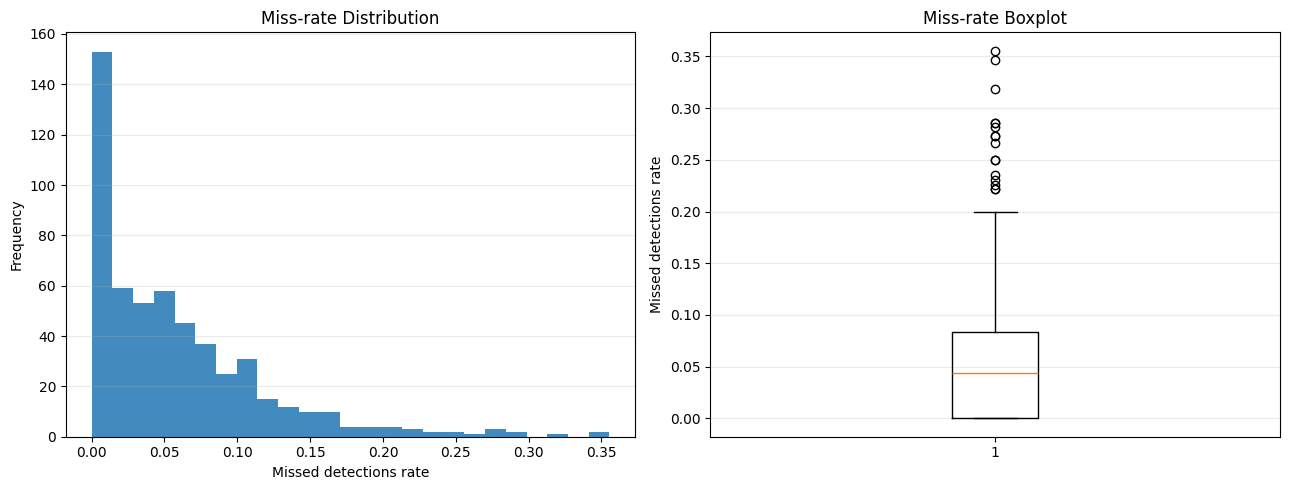

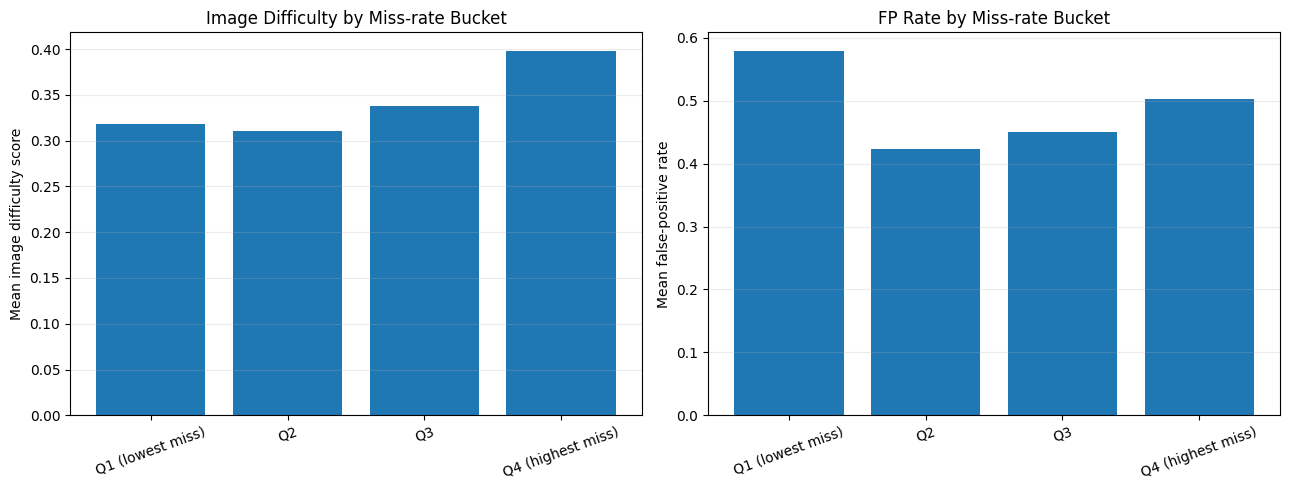


Top worst miss-rate images
 1. miss=0.3556 | score=0.5015 | fp=0.4222 | objs= 45 | /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/train/images/20150921_132038_image71.png
 2. miss=0.3462 | score=0.4445 | fp=0.6538 | objs= 26 | /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/train/images/20150921_131833_image1.png
 3. miss=0.3182 | score=0.4545 | fp=0.4091 | objs= 44 | /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/train/images/20150921_132038_image76.png
 4. miss=0.2857 | score=0.5623 | fp=0.7143 | objs=  7 | /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/train/images/20150919_174730_image261.png
 5. miss=0.2857 | score=0.4422 | fp=0.8571 | objs=  7 | /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/train/images/20150919_174730_image66.png
 6. miss=0.2817 | score=0.4513 | fp=0.2817 | objs= 71 | /home/khanh

In [10]:
# Miss-rate analysis
valid_miss = ~np.isnan(miss_rates)
if np.sum(valid_miss) == 0:
    raise ValueError('No valid missed_detections_rate values available.')

miss_valid = miss_rates[valid_miss]
img_scores_valid = img_scores[valid_miss]
fp_valid = fp_rates[valid_miss]

print('Miss-rate summary statistics')
print(f'- valid images: {len(miss_valid)} / {len(miss_rates)}')
print(f'- mean: {np.mean(miss_valid):.4f}')
print(f'- std: {np.std(miss_valid):.4f}')
print(f'- median: {np.median(miss_valid):.4f}')
print(f'- p90: {np.quantile(miss_valid, 0.90):.4f}')
print(f'- p95: {np.quantile(miss_valid, 0.95):.4f}')
print(f'- p99: {np.quantile(miss_valid, 0.99):.4f}')
print(f'- max: {np.max(miss_valid):.4f}')

# Distribution views
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].hist(miss_valid, bins=25, alpha=0.85)
ax[0].set_xlabel('Missed detections rate')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Miss-rate Distribution')
ax[0].grid(axis='y', alpha=0.25)

ax[1].boxplot(miss_valid, vert=True)
ax[1].set_ylabel('Missed detections rate')
ax[1].set_title('Miss-rate Boxplot')
ax[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

# Difficulty impact by miss-rate quantile bucket
q_edges = np.quantile(miss_valid, [0.0, 0.25, 0.5, 0.75, 1.0])
for i in range(1, len(q_edges)):
    if q_edges[i] <= q_edges[i - 1]:
        q_edges[i] = q_edges[i - 1] + 1e-12

bucket_ids = np.digitize(miss_valid, q_edges[1:-1], right=True)
bucket_labels = ['Q1 (lowest miss)', 'Q2', 'Q3', 'Q4 (highest miss)']
mean_img_score_by_bucket = [
    float(np.mean(img_scores_valid[bucket_ids == i])) if np.any(bucket_ids == i) else np.nan
    for i in range(4)
]
mean_fp_by_bucket = [
    float(np.mean(fp_valid[bucket_ids == i])) if np.any(bucket_ids == i) else np.nan
    for i in range(4)
]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].bar(bucket_labels, mean_img_score_by_bucket)
ax[0].set_ylabel('Mean image difficulty score')
ax[0].set_title('Image Difficulty by Miss-rate Bucket')
ax[0].tick_params(axis='x', rotation=20)
ax[0].grid(axis='y', alpha=0.25)

ax[1].bar(bucket_labels, mean_fp_by_bucket)
ax[1].set_ylabel('Mean false-positive rate')
ax[1].set_title('FP Rate by Miss-rate Bucket')
ax[1].tick_params(axis='x', rotation=20)
ax[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

# Top-k worst miss-rate images
k = 10
miss_items = []
for img in image_difficulties:
    mr = img.get('missed_detections_rate', None)
    if mr is None:
        continue
    miss_items.append({
        'image_path': img.get('image_path', ''),
        'miss_rate': float(mr),
        'image_score': float(img.get('difficulty_score', np.nan)),
        'fp_rate': float(img.get('false_positive_rate', np.nan)),
        'num_objects': int(img.get('num_objects', 0)),
    })

miss_items = sorted(miss_items, key=lambda x: x['miss_rate'], reverse=True)
worst_items = miss_items[:k]

print('\nTop worst miss-rate images')
for i, item in enumerate(worst_items, start=1):
    print(
        f"{i:2d}. miss={item['miss_rate']:.4f} | "
        f"score={item['image_score']:.4f} | "
        f"fp={item['fp_rate']:.4f} | "
        f"objs={item['num_objects']:3d} | "
        f"{item['image_path']}"
    )